In [2]:
import sys
print(sys.executable)


C:\Users\dudyala guru sreekar\anaconda3\envs\ml_env\python.exe


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import cv2
import numpy as np

In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
import torch

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values.astype(np.float32)
y = mnist.target.values.astype(np.int64)

print("Original pixel range:", X.min(), X.max())

Original pixel range: 0.0 255.0


In [13]:


X = X / 255.0


print("After normalization:", X.min(), X.max())

After normalization: 0.0 1.0


In [14]:
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

X_tensor = X_tensor.view(-1, 1, 28, 28)

print(X_tensor.shape)


torch.Size([70000, 1, 28, 28])


In [15]:
X_train = X_tensor[:60000]
y_train = y_tensor[:60000]

X_test = X_tensor[60000:]
y_test = y_tensor[60000:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: torch.Size([60000, 1, 28, 28])
Test shape: torch.Size([10000, 1, 28, 28])


In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

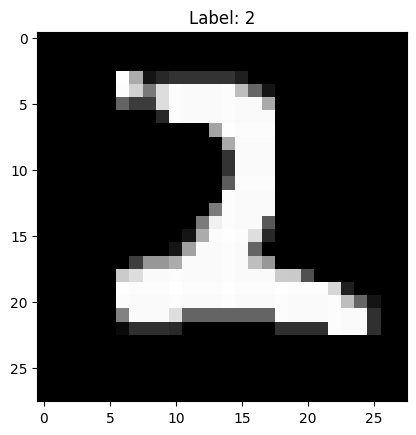

In [17]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [18]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [19]:
import torch.nn as nn
import torch.optim as optim

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model, Loss, Optimizer ready")

Model, Loss, Optimizer ready


In [20]:
epochs =6

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2448
Epoch 2, Loss: 0.0612
Epoch 3, Loss: 0.0437
Epoch 4, Loss: 0.0331
Epoch 5, Loss: 0.0259
Epoch 6, Loss: 0.0199


In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.92%


In [22]:
print("Min pixel:", X_train.min().item())
print("Max pixel:", X_train.max().item())
print("Label dtype:", y_train.dtype)

Min pixel: 0.0
Max pixel: 1.0
Label dtype: torch.int64


In [23]:
import torch.nn.functional as F

images, labels = next(iter(test_loader))

outputs = model(images)
probabilities = F.softmax(outputs, dim=1)

print("Predicted probabilities for first image:")
print(probabilities[0])
print("Predicted digit:", torch.argmax(probabilities[0]).item())
print("True digit:", labels[0].item())

Predicted probabilities for first image:
tensor([4.4775e-11, 2.4353e-07, 1.6677e-08, 1.1565e-06, 1.4150e-10, 1.5006e-09,
        8.1143e-15, 1.0000e+00, 3.0075e-10, 4.3983e-07],
       grad_fn=<SelectBackward0>)
Predicted digit: 7
True digit: 7


In [24]:
import torch

torch.save(model.state_dict(), "digit_model.pth")

In [25]:
import os
print("Current directory:", os.getcwd())
print("Files in folder:", os.listdir())

Current directory: C:\Users\dudyala guru sreekar\AIproject-\MODELS
Files in folder: ['.ipynb_checkpoints', 'digitpredictor.ipynb', 'digit_model.pth', 'digit_model_augmented.pth', 'digit_model_finetuned.pth', 'rotated_test.jpg', 'syn90k .ipynb']


In [26]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(1568, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [27]:
import torch

dummy = torch.randn(1,1,28,28)

with torch.no_grad():
    output = model(dummy)

print(output.shape)

torch.Size([1, 10])


In [28]:
import cv2
import numpy as np

def preprocess_image(image_path):
   
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found")
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Remove noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Adaptive threshold for uneven lighting
    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        print("No digit detected")
        return None

    # Get largest contour (assume digit)
    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 100:
        print("Detected object too small")
        return None

    x, y, w, h = cv2.boundingRect(largest)
    digit = thresh[y:y+h, x:x+w]

    # Resize to 28x28
    digit = cv2.resize(digit, (28,28))

    # Normalize
    digit = digit / 255.0

    return digit

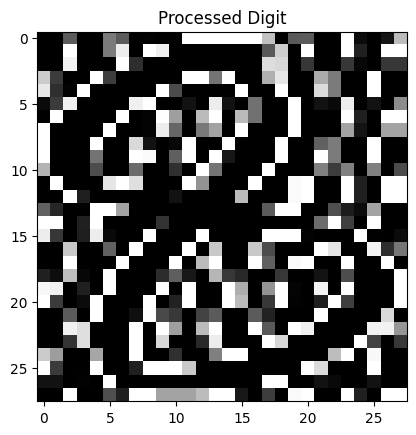

In [29]:
import matplotlib.pyplot as plt

processed = preprocess_image(r"C:\Users\dudyala guru sreekar\Downloads\images.png")

plt.imshow(processed, cmap='gray')
plt.title("Processed Digit")
plt.show()

In [30]:
def preprocess_clean_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Resize directly
    img = cv2.resize(img, (28,28))

    # Invert if background is white
    if np.mean(img) > 127:
        img = 255 - img

    img = img / 255.0

    return img

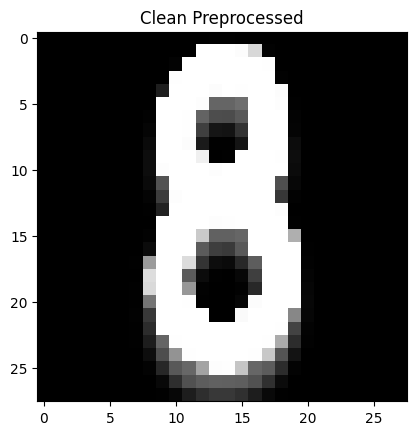

In [31]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

plt.imshow(processed, cmap="gray")
plt.title("Clean Preprocessed")
plt.show()

In [32]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(1568, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [33]:
model = CNN()
model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [34]:
print(predict_digit(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg"))

NameError: name 'predict_digit' is not defined

In [35]:
import cv2
import numpy as np

img = cv2.imread(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

(h, w) = img.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 20, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

cv2.imwrite("rotated_test.jpg", rotated)

True

In [36]:
print(predict_digit("rotated_test.jpg"))

NameError: name 'predict_digit' is not defined

In [37]:
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset

# ----------------------------
# 1️⃣ Define Augmentation
# ----------------------------

train_transform = transforms.Compose([
    transforms.RandomRotation(35),   # wider rotation range
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),      # stronger shift
        scale=(0.85, 1.15)           # slight zoom in/out
    ),
])

test_transform = transforms.Compose([])

# ----------------------------
# 2️⃣ Custom Dataset Wrapper
# ----------------------------

class AugmentedDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# ----------------------------
# 3️⃣ Create Augmented Datasets
# ----------------------------

train_dataset = AugmentedDataset(X_train, y_train, transform=train_transform)
test_dataset  = AugmentedDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [38]:
torch.save(model.state_dict(), "digit_model_augmented.pth")
print("Augmented model saved")

Augmented model saved


In [39]:
print(predict_digit("rotated_test.jpg"))

NameError: name 'predict_digit' is not defined

In [40]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

print(type(processed))
print(processed.shape if processed is not None else "None")

<class 'numpy.ndarray'>
(28, 28)


In [41]:
tensor = torch.tensor(processed, dtype=torch.float32)
tensor = tensor.unsqueeze(0).unsqueeze(0)

print(tensor.shape)

torch.Size([1, 1, 28, 28])


In [42]:
with torch.no_grad():
    output = model(tensor)

print(output.shape)

torch.Size([1, 10])


In [43]:
probs = F.softmax(output, dim=1)
confidence, predicted = torch.max(probs, 1)

print("Digit:", predicted.item())
print("Confidence:", confidence.item())

Digit: 8
Confidence: 0.9991416931152344


In [44]:
CONF_THRESHOLD = 0.85

def predict_digit(image_path):

    processed = preprocess_clean_image(image_path)

    if processed is None:
        return {"status": "no_digit_detected"}

    tensor = torch.tensor(processed, dtype=torch.float32)
    tensor = tensor.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    confidence = confidence.item()
    predicted = predicted.item()

    if confidence < CONF_THRESHOLD:
        return {
            "status": "uncertain",
            "confidence": confidence
        }

    return {
        "status": "success",
        "digit": predicted,
        "confidence": confidence
    }

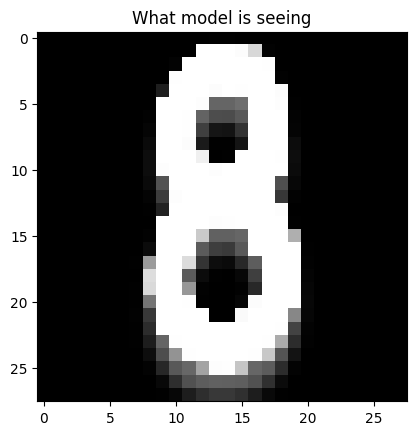

In [45]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

import matplotlib.pyplot as plt
plt.imshow(processed, cmap="gray")
plt.title("What model is seeing")
plt.show()

In [46]:
print(predict_digit("rotated_test.jpg"))

{'status': 'success', 'digit': 6, 'confidence': 0.9539875388145447}


In [47]:
print("Model path being used: digit_model_augmented.pth")

Model path being used: digit_model_augmented.pth


In [48]:
model = CNN()
model.load_state_dict(torch.load("digit_model_augmented.pth", weights_only=True))
model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [49]:
old_model = CNN()
old_model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
old_model.eval()

aug_model = CNN()
aug_model.load_state_dict(torch.load("digit_model_augmented.pth", weights_only=True))
aug_model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [50]:
def test_model(model_obj, image_path):
    processed = preprocess_clean_image(image_path)
    tensor = torch.tensor(processed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model_obj(tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    return predicted.item(), confidence.item()

In [51]:
print("Old:", test_model(old_model, "rotated_test.jpg"))
print("Aug:", test_model(aug_model, "rotated_test.jpg"))

Old: (6, 0.9539875388145447)
Aug: (6, 0.9539875388145447)


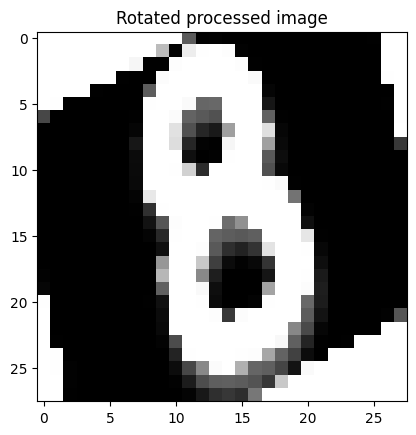

In [52]:
processed_rot = preprocess_clean_image("rotated_test.jpg")

plt.imshow(processed_rot, cmap="gray")
plt.title("Rotated processed image")
plt.show()

In [53]:
import cv2
import numpy as np

def rotate_with_padding(image, angle):
    h, w = image.shape[:2]

    # compute diagonal to prevent clipping
    diagonal = int(np.sqrt(h*h + w*w))

    padded = np.zeros((diagonal, diagonal), dtype=image.dtype)

    # center original inside padded canvas
    x_offset = (diagonal - w) // 2
    y_offset = (diagonal - h) // 2
    padded[y_offset:y_offset+h, x_offset:x_offset+w] = image

    center = (diagonal // 2, diagonal // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(padded, M, (diagonal, diagonal))

    # crop bounding box again
    coords = cv2.findNonZero(rotated)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = rotated[y:y+h, x:x+w]

    resized = cv2.resize(cropped, (28, 28))

    return resized

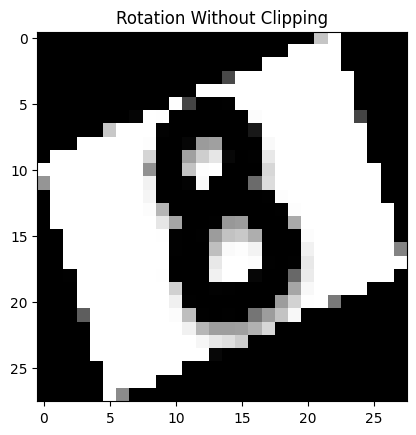

In [54]:
orig = cv2.imread(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg", cv2.IMREAD_GRAYSCALE)
rot_fixed = rotate_with_padding(orig, 20)

plt.imshow(rot_fixed, cmap="gray")
plt.title("Rotation Without Clipping")
plt.show()

In [55]:
def preprocess_camera_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Adaptive threshold for uneven lighting
    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )
    kernel = np.ones((2,2), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=5)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(largest)
    digit = thresh[y:y+h, x:x+w]

    # Preserve aspect ratio
    h, w = digit.shape
    if h > w:
        new_h = 20
        new_w = int(w * (20/h))
    else:
        new_w = 20
        new_h = int(h * (20/w))

    digit = cv2.resize(digit, (new_w, new_h))

    # Pad to 28x28
    pad_x = (28 - new_w)//2
    pad_y = (28 - new_h)//2

    digit = np.pad(
        digit,
        ((pad_y, 28-new_h-pad_y),
         (pad_x, 28-new_w-pad_x)),
        mode="constant"
    )

    digit = digit / 255.0

    return digit

In [56]:
mnist_sample, _ = train_dataset[0]
print(torch.sum(mnist_sample).item())

119.05490112304688


48.21176470588236


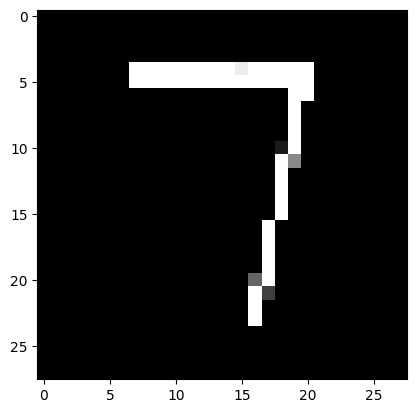

In [57]:
processed = preprocess_camera_image(r"C:\Users\dudyala guru sreekar\Downloads\7.jpeg")

plt.imshow(processed, cmap="gray")
print(np.sum(processed))
plt.show()

In [58]:
def predict_camera_digit(image_path, threshold=0.85):

    processed = preprocess_camera_image(image_path)
    
    if processed is None:
        return {"status": "no_digit_detected"}

    tensor = torch.tensor(processed, dtype=torch.float32)
    tensor = tensor.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    confidence = confidence.item()
    predicted = predicted.item()

    if confidence < threshold:
        return {
            "status": "uncertain",
            "confidence": confidence
        }

    return {
        "status": "success",
        "digit": predicted,
        "confidence": confidence
    }

In [61]:
print(predict_camera_digit(r"C:\Users\dudyala guru sreekar\Downloads\5.jpeg"))

{'status': 'success', 'digit': 5, 'confidence': 0.9997897744178772}


In [102]:
def preprocess_multiple_digits(image_path):
    import cv2
    import numpy as np

    img = cv2.imread(image_path)
    if img is None:
        return []

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Compute vertical projection
    col_sum = np.sum(thresh, axis=0)

    # Detect split points where column sum is near zero
    split_positions = []
    threshold = np.max(col_sum) * 0.05

    for i in range(len(col_sum)):
        if col_sum[i] < threshold:
            split_positions.append(i)

    # Group continuous zero columns
    splits = []
    start = None

    for i in split_positions:
        if start is None:
            start = i
        elif i - prev > 1:
            splits.append((start, prev))
            start = i
        prev = i

    if start is not None:
        splits.append((start, prev))

    # Extract digit regions
    digit_images = []
    prev_end = 0

    for (s, e) in splits:
        if s - prev_end > 5:
            digit = thresh[:, prev_end:s]

            if digit.shape[1] > 5:
                digit = cv2.resize(digit, (28, 28))
                digit = digit / 255.0
                digit_images.append(digit)

        prev_end = e

    return digit_images

In [1]:
predict_multiple_digits(r"C:\Users\dudyala guru sreekar\Downloads\987.jpeg")

NameError: name 'predict_multiple_digits' is not defined

In [47]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Lambda(lambda img: img.getchannel("A")),
    transforms.ToTensor()
])


dataset_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset"

hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

print("Total samples:", len(hand_dataset))

Total samples: 107730


In [48]:
model = CNN()
model.load_state_dict(torch.load("digit_model_augmented.pth", weights_only=True))
model.train()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [49]:
hand_loader = DataLoader(
    hand_dataset,
    batch_size=32,
    shuffle=True
)

print("DataLoader ready")

DataLoader ready


In [50]:
images, labels = next(iter(hand_loader))

print(images.shape)
print(torch.min(images), torch.max(images))
print(torch.sum(images[0]))
print(torch.sum(images[1]))

torch.Size([32, 1, 28, 28])
tensor(0.) tensor(0.)
tensor(0.)
tensor(0.)


In [51]:
model.train()
print("Model in training mode")

Model in training mode


In [52]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 2

for epoch in range(epochs):
    total_loss = 0

    for images, labels in hand_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 7755.0060
Epoch 2, Loss: 7753.3025


In [53]:
torch.save(model.state_dict(), "digit_model_finetuned.pth")
print("Fine-tuned model saved")

Fine-tuned model saved


In [54]:
model.eval()
print("Model ready for testing")

Model ready for testing


In [55]:
print(predict_multiple_digits(r"C:\Users\dudyala guru sreekar\Downloads\987.jpeg"))

{'digits': ['?', '8', '3'], 'number': '883'}


In [56]:
print(hand_dataset.class_to_idx)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


In [57]:
print(f"Epoch {epoch+1}, Avg Loss: {total_loss / len(hand_loader):.4f}")

Epoch 2, Avg Loss: 2.3027


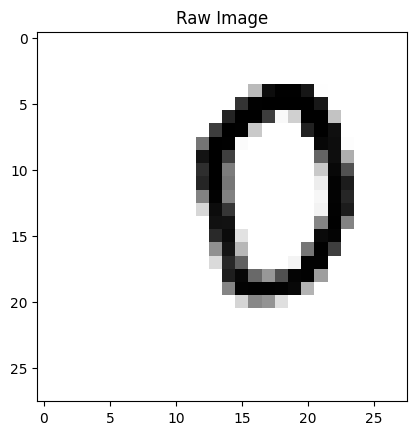

RGBA


In [58]:
from PIL import Image
import os
import matplotlib.pyplot as plt

root = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\0"

file = os.listdir(root)[0]
img_path = os.path.join(root, file)

img = Image.open(img_path)
plt.imshow(img)
plt.title("Raw Image")
plt.show()

print(img.mode)

In [59]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset"


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

print("Total samples:", len(hand_dataset))
print("Classes:", hand_dataset.class_to_idx)

Total samples: 107730
Classes: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


In [60]:
hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

images, labels = next(iter(hand_loader))

print("Shape:", images.shape)
print("Min:", torch.min(images))
print("Max:", torch.max(images))
print("Sum image 0:", torch.sum(images[0]))

Shape: torch.Size([32, 1, 28, 28])
Min: tensor(0.)
Max: tensor(0.)
Sum image 0: tensor(0.)


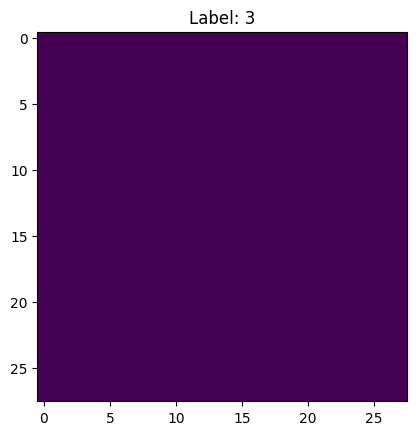

In [61]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1,2,0))
plt.title(f"Label: {labels[1].item()}")
plt.show()

In [62]:
from PIL import Image
import os

sample_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\9"
file = os.listdir(sample_path)[0]
img = Image.open(os.path.join(sample_path, file))

print("Mode:", img.mode)

Mode: RGBA


In [63]:
hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

images, labels = next(iter(hand_loader))

print("Min:", torch.min(images))
print("Max:", torch.max(images))
print("Sum image 0:", torch.sum(images[0]))

Min: tensor(0.)
Max: tensor(0.)
Sum image 0: tensor(0.)


Mode: RGBA
Size: (28, 28)


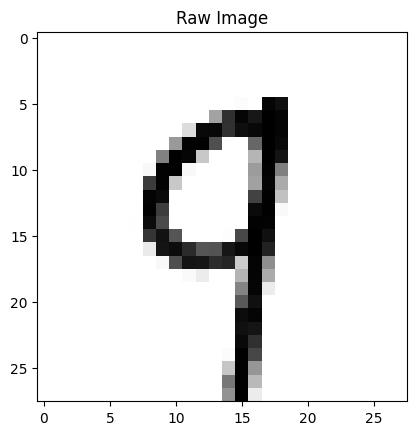

In [64]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\9\997.png"

img = Image.open(img_path)
print("Mode:", img.mode)
print("Size:", img.size)

plt.imshow(img)
plt.title("Raw Image")
plt.show()

In [65]:
import numpy as np

img_array = np.array(img)
print(img_array.shape)
print(np.unique(img_array))

(28, 28, 4)
[  0   1   2   3   4   5   6   7  19  21  35  52  55  57  62  70  74  75
  84  85  93  94  99 102 105 109 113 123 126 127 136 152 167 169 170 172
 176 181 183 184 189 194 196 202 206 207 211 212 218 221 232 233 234 235
 236 237 239 240 241 243 244 245 246 247 250 251 252 253 254 255]


In [66]:
images, labels = next(iter(hand_loader))

print("Shape:", images.shape)
print("Min:", torch.min(images))
print("Max:", torch.max(images))
print("Sum image 0:", torch.sum(images[0]))

Shape: torch.Size([32, 1, 28, 28])
Min: tensor(0.)
Max: tensor(0.)
Sum image 0: tensor(0.)


Unique values: [0]
Min: 0
Max: 0


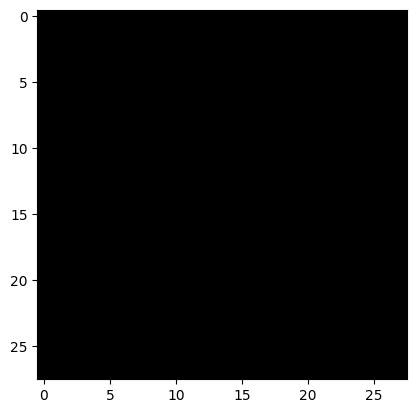

In [67]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

img_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\9\997.png"

# Load image
img = Image.open(img_path)

# Convert to grayscale
img_gray = img.convert("L")

# Resize
img_gray = img_gray.resize((28,28))

# Convert to numpy
img_np = np.array(img_gray)

print("Unique values:", np.unique(img_np))
print("Min:", img_np.min())
print("Max:", img_np.max())

plt.imshow(img_np, cmap="gray")
plt.show()

In [68]:
hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

images, labels = next(iter(hand_loader))

print("Shape:", images.shape)
print("Min:", torch.min(images))
print("Max:", torch.max(images))
print("Sum image 0:", torch.sum(images[0]))

Shape: torch.Size([32, 1, 28, 28])
Min: tensor(0.)
Max: tensor(0.)
Sum image 0: tensor(0.)


In [69]:
import os

dataset_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\9"

print("Files inside 9 folder:")
print(os.listdir(dataset_path)[:10])

Files inside 9 folder:
['0.png', '1.png', '10.png', '100.png', '1000.png', '10000.png', '10001.png', '10002.png', '10003.png', '10004.png']


Shape: (28, 28, 4)
Min: 0
Max: 255
Unique sample: [ 0  1  7  8 11 16 17 18 27 56]


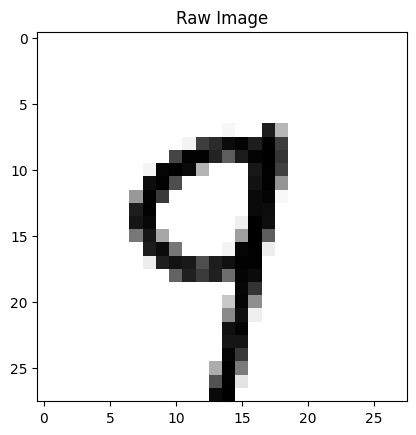

In [71]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset\9\0.png"

img = Image.open(img_path)
img_np = np.array(img)

print("Shape:", img_np.shape)
print("Min:", img_np.min())
print("Max:", img_np.max())
print("Unique sample:", np.unique(img_np)[:10])

plt.imshow(img_np)
plt.title("Raw Image")
plt.show()

In [80]:
from PIL import Image

def rgba_loader(path):
    return Image.open(path)   # DO NOT convert to RGB


In [81]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = r"C:\Users\dudyala guru sreekar\Downloads\archive\dataset"

transform = transforms.Compose([
    transforms.Lambda(
        lambda img: img.getchannel("A") if img.mode == "RGBA"
        else img.convert("L")
    ),
    transforms.ToTensor()
])

hand_dataset = datasets.ImageFolder(
    root=dataset_path,
    loader=rgba_loader,  # now defined
    transform=transform
)

hand_loader = DataLoader(hand_dataset, batch_size=32, shuffle=True)

In [82]:
images, labels = next(iter(hand_loader))

print("Shape:", images.shape)
print("Min:", images.min().item())
print("Max:", images.max().item())
print("Sum first image:", images[0].sum().item())

Shape: torch.Size([32, 1, 28, 28])
Min: 0.0
Max: 1.0
Sum first image: 60.28627014160156


In [83]:
model.train()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 2

for epoch in range(epochs):
    total_loss = 0

    for images, labels in hand_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Avg Loss: {total_loss / len(hand_loader):.4f}")

Epoch 1, Avg Loss: 0.0148
Epoch 2, Avg Loss: 0.0009


In [84]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in hand_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Training Accuracy:", 100 * correct / total

Training Accuracy: 100.0


In [106]:
import torch
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, num_classes=11):  # 10 digits + blank
        super(CRNN, self).__init__()

        # CNN backbone
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),  # H/2

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),  # H/4

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
        )

        # BiLSTM
        self.rnn = nn.LSTM(
            input_size=256 * 7,  # height reduced to 7 (28/4)
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x: (B,1,H,W)
        features = self.cnn(x)
        B, C, H, W = features.size()

        # reshape to sequence
        features = features.permute(0, 3, 1, 2)  # (B,W,C,H)
        features = features.contiguous().view(B, W, C*H)

        seq, _ = self.rnn(features)

        output = self.fc(seq)

        return output  # (B, W, num_classes)

In [107]:
ctc_loss = nn.CTCLoss(blank=10, zero_infinity=True)

In [108]:
def decode_predictions(preds):
    preds = torch.argmax(preds, dim=2)
    results = []

    for seq in preds:
        string = []
        prev = -1
        for p in seq:
            p = p.item()
            if p != prev and p != 10:  # remove blanks & repeats
                string.append(str(p))
            prev = p
        results.append("".join(string))

    return results

In [2]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
base_model = CNN()
base_model.load_state_dict(torch.load("digit_model.pth"))
base_model.eval()

aug_model = CNN()
aug_model.load_state_dict(torch.load("digit_model_augmented.pth"))
aug_model.eval()

finetuned_model = CNN()
finetuned_model.load_state_dict(torch.load("digit_model_finetuned.pth"))
finetuned_model.eval()

C:\Users\dudyala guru sreekar\AppData\Local\Temp\ipykernel_26120\914608810.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load("digit_m

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [4]:
for name, model in {
    "Base": base_model,
    "Augmented": aug_model,
    "Finetuned": finetuned_model
}.items():
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name} model loaded | Parameters: {total_params}")

Base model loaded | Parameters: 206922
Augmented model loaded | Parameters: 206922
Finetuned model loaded | Parameters: 206922


In [7]:
def load_model(path):
    model = CNN()
    model.load_state_dict(torch.load(path, weights_only=True))
    model.eval()
    return model

base_model = load_model("digit_model.pth")
aug_model = load_model("digit_model_augmented.pth")
finetuned_model = load_model("digit_model_finetuned.pth")

In [8]:
import cv2
import numpy as np
import torch.nn.functional as F

def predict_camera_digit(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    gray = cv2.resize(gray, (28, 28))
    gray = gray.astype("float32") / 255.0
    
    tensor = torch.tensor(gray).unsqueeze(0).unsqueeze(0)
    
    with torch.no_grad():
        output = finetuned_model(tensor)
        prob = F.softmax(output, dim=1)
        confidence, pred = torch.max(prob, 1)
    
    return pred.item(), confidence.item()

In [9]:
print(predict_camera_digit(r"C:\Users\dudyala guru sreekar\Downloads\7.jpeg"))

(3, 0.9543231129646301)
